# Small Bodies at Every Scale: from the Asteroid Belt to the Oort Cloud

#### This tutorial rebuilds a familiar "three-panel" picture of the Solar System's small bodies — but from real orbit data, at the correct relative scale, on the day of your choosing.

Popular-science graphics such as ESA's [*Small objects in the Solar System*](https://www.esa.int/ESA_Multimedia/Search?SearchText=Small+objects+in+the+Solar+System) infographic show the Solar System in three nested views, each seen obliquely from above the ecliptic:

1. the **inner Solar System**, with the main asteroid belt as a dusty ring between Mars and Jupiter;
2. the **outer Solar System**, zoomed out to show the Kuiper belt beyond Neptune;
3. the **Oort cloud**, a vast spherical halo around the whole planetary system.

Those cartoons are *representative*, not to scale, and drawn by an artist. Here we draw the same three views ourselves. The first two panels use **only MPC data** — the positions of every one of the roughly 1.5 million objects in [`MPCORB.DAT`](https://minorplanetcenter.net/iau/MPCORB.html) on the catalogue epoch — so their asteroid belt and Kuiper belt are the *real* populations, with all their asymmetries, gaps and observational biases. The third panel is different: no Oort-cloud object has ever been observed *in* the cloud, so the halo is drawn from a simple statistical model taken from the dynamical literature, wrapped around the real planetary system on a **logarithmic radial scale** that lets 0.4 AU and 100 000 AU share one picture.

Along the way we build a small, reusable "oblique camera" for turning heliocentric (x, y, z) coordinates into the tilted perspective of the infographic, and finish with a single three-panel figure in the style of the original.

This notebook reuses the MPCORB download-and-parse pipeline and the vectorized Kepler solver from the [Kirkwood gaps tutorial](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_kirkwood/); see that tutorial and the [orbit plotting tutorial](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_plotting/) for a step-by-step explanation of those pieces.

## Environment Setup

This notebook requires `rebound`, `matplotlib`, `numpy`, and `requests`. We recommend creating a dedicated conda environment and registering it as a Jupyter kernel so that all dependencies are isolated and reproducible.

Run the following commands once in a terminal before opening this notebook:

```bash
# Create and populate the environment
conda create -n orbit-tutorial python=3.11 -y
conda activate orbit-tutorial
pip install rebound mpc-orb astropy matplotlib numpy requests ipykernel

# Register the environment as a Jupyter kernel
python -m ipykernel install --user --name orbit-tutorial --display-name "Python (orbit-tutorial)"
```

If you do not already have a way of running Jupyter notebooks, also install Jupyter itself (`pip install jupyter`), then launch it from the directory containing this notebook with:

```bash
jupyter notebook
```

and open this file in the browser tab that appears. However you run the notebook, select **Kernel > Change Kernel > Python (orbit-tutorial)** before running the cells below.

If you already created the `orbit-tutorial` environment for the companion tutorials, you can simply reuse it — no new packages are needed.

# Install and Import Packages

We need `requests` to download the catalogue, `numpy` and `matplotlib` for the computation and the figures, and `rebound` to fetch the planets from JPL Horizons.

In [1]:
import os
import gzip
import collections

import requests
import numpy as np
import matplotlib.pyplot as plt

import rebound

# Step 1: Download and Parse MPCORB

Our data source is the MPC's flagship orbit file, [`MPCORB.DAT`](https://minorplanetcenter.net/iau/MPCORB.html): roughly 1.5 million orbits in a fixed-width text format (about 90 MB gzipped), with the column layout documented on the [Minor Planet Orbit Format page](https://docs.minorplanetcenter.net/mpc-ops-docs/orbits/minor-planet-orbit-format/). Bulk orbit files are listed on the [MPC data page](https://minorplanetcenter.net/data).

The cell below is the parsing pipeline from the [Kirkwood gaps tutorial](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_kirkwood/): it streams the gzipped file, slices the six Keplerian elements and the packed epoch code out of each line, and counts how many orbits share each epoch. This time we keep **everything** — near-Earth objects, the main belt, Trojans, Centaurs and trans-Neptunian objects alike — because the outer panels need the distant populations.

**Download note:** the cell caches `MPCORB.DAT.gz` (about 90 MB) in the notebook's working directory and only downloads it if it is not already present. Delete the file to reclaim the space when you are done.

In [2]:
MPCORB_URL = "https://www.minorplanetcenter.net/iau/MPCORB/MPCORB.DAT.gz"
MPCORB_FILE = "MPCORB.DAT.gz"

if not os.path.exists(MPCORB_FILE):
    print(f"Downloading {MPCORB_URL} (about 90 MB; this may take a few minutes)")
    with requests.get(MPCORB_URL, stream=True, timeout=600) as r:
        r.raise_for_status()
        with open(MPCORB_FILE + ".part", "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                f.write(chunk)
    os.rename(MPCORB_FILE + ".part", MPCORB_FILE)
    print("  done")
else:
    print(f"Using cached {MPCORB_FILE}")

# Fixed-width columns (1-indexed, from the orbit-format documentation):
# epoch 21-25 (packed), M 27-35, Peri 38-46, Node 49-57,
# i 60-68, e 71-79, a 93-103
rows = []
epoch_counts = collections.Counter()
with gzip.open(MPCORB_FILE, "rt") as f:
    in_header = True
    for line in f:
        if in_header:                      # header ends at a dashed line
            if line.startswith("----------"):
                in_header = False
            continue
        if len(line) < 104:                # skip blank section separators
            continue
        try:
            elems = (float(line[92:103]), float(line[70:79]),
                     float(line[59:68]), float(line[48:57]),
                     float(line[37:46]), float(line[26:35]))
        except ValueError:                 # rare rows with missing elements
            continue
        rows.append(elems + (line[20:25],))
        epoch_counts[line[20:25]] += 1

print(f"\nParsed {len(rows):,} orbits")
epoch_mode, n_mode = epoch_counts.most_common(1)[0]
print(f"Most common epoch: {epoch_mode!r} ({n_mode:,} orbits, "
      f"{100 * n_mode / len(rows):.1f} percent of the catalogue)")

Using cached MPCORB.DAT.gz



Parsed 1,562,078 orbits
Most common epoch: 'K2669' (1,552,194 orbits, 99.4 percent of the catalogue)


# Step 2: Positions of the Whole Catalogue at the Common Epoch

Almost the whole catalogue shares one standard epoch, so we keep the orbits at that modal epoch (bound orbits only, `e < 1`), and place every object at its position on that date by solving Kepler's equation `E − e sin E = M` for all objects at once with a few vectorized Newton iterations, then rotating the in-plane positions into the heliocentric ecliptic frame. This is exactly the solver from the Kirkwood tutorial (where it was cross-checked against REBOUND); the only change is that there is no cut on semi-major axis, so the trans-Neptunian objects survive.

We also tag each object with a coarse **dynamical class** from its elements, purely for colouring: near-Earth objects (perihelion `q < 1.3 AU`), the main belt, the Hildas and Jupiter Trojans, the Centaurs between Jupiter and Neptune, and the trans-Neptunian objects (`a ≥ 30 AU`).

In [3]:
el = np.array([r[:6] for r in rows if r[6] == epoch_mode])
el = el[(el[:, 0] > 0) & (el[:, 1] < 1.0)]
print(f"{len(el):,} bound orbits at the common epoch")

a, e = el[:, 0], el[:, 1]
inc, node, peri, M = np.radians(el[:, 2:6]).T

E = M.copy()                             # solve Kepler: E - e sin E = M
for _ in range(30):                      # Newton iterations, all objects at once
    E -= (E - e * np.sin(E) - M) / (1 - e * np.cos(E))

xp = a * (np.cos(E) - e)                 # position in the orbital plane
yp = a * np.sqrt(1 - e**2) * np.sin(E)

cw, sw = np.cos(peri), np.sin(peri)      # rotate: R_z(node) R_x(inc) R_z(peri)
ci, si = np.cos(inc), np.sin(inc)
cO, sO = np.cos(node), np.sin(node)
x1, y1 = cw * xp - sw * yp, sw * xp + cw * yp
y2, z = ci * y1, si * y1
x = cO * x1 - sO * y2
y = sO * x1 + cO * y2
r = np.sqrt(x**2 + y**2 + z**2)

# Coarse dynamical classes, for colouring only
q = a * (1 - e)
cls = np.full(len(a), "belt", dtype=object)
cls[q < 1.3] = "neo"
cls[(a >= 3.7) & (a < 5.5) & (q >= 1.3)] = "hilda_trojan"
cls[(a >= 5.5) & (a < 30.0) & (q >= 1.3)] = "centaur"
cls[a >= 30.0] = "tno"

for name in ["neo", "belt", "hilda_trojan", "centaur", "tno"]:
    print(f"{name:>13}: {np.sum(cls == name):>9,}")

1,552,194 bound orbits at the common epoch


          neo:    42,177
         belt: 1,477,476
 hilda_trojan:    24,693
      centaur:       986
          tno:     6,862


# Step 3: The Planets from JPL Horizons

For context we need the Sun and the eight planets at the same instant. We decode the packed epoch (e.g. `K2669` → 2026-06-09; see the [packed dates documentation](https://docs.minorplanetcenter.net/mpc-ops-docs/designations/packed-dates/)), ask REBOUND to fetch each body from [JPL Horizons](https://ssd.jpl.nasa.gov/horizons/) on that date, and sample each planet's orbit as a set of 3-D points so it can be drawn from any viewpoint. The simulation is set to the same `(AU, day, Msun)` units as the MPC elements, so the planets and asteroids share one coordinate frame.

In [4]:
def unpack_epoch(packed):
    century = {"I": 18, "J": 19, "K": 20}[packed[0]]
    year = century * 100 + int(packed[1:3])
    month = int(packed[3], 36) if packed[3].isdigit() else ord(packed[3]) - 55
    day = int(packed[4], 36) if packed[4].isdigit() else ord(packed[4]) - 55
    return year, month, day

yr, mon, day = unpack_epoch(epoch_mode)
epoch_date = f"{yr:04d}-{mon:02d}-{day:02d}"
print(f"Catalogue epoch: {epoch_date}")

PLANETS = ["Mercury", "Venus", "Earth", "Mars", "Jupiter", "Saturn", "Uranus", "Neptune"]
PLANET_COLOR = {"Mercury": "#b5b5b5", "Venus": "#e8d9a8", "Earth": "#4f9de6",
                "Mars": "#e0663c", "Jupiter": "#d9b98a", "Saturn": "#e6cf8a",
                "Uranus": "#9fe1e8", "Neptune": "#5b7fe6"}
PLANET_SIZE = {"Mercury": 14, "Venus": 22, "Earth": 24, "Mars": 18,     # representative,
               "Jupiter": 80, "Saturn": 66, "Uranus": 40, "Neptune": 38}   # not to scale
PLANET_LABEL_OFFSET = {"Mercury": (5, -11), "Venus": (-38, 4), "Earth": (6, -12), "Mars": (7, 4),
                       "Jupiter": (8, 5), "Saturn": (8, 5), "Uranus": (8, 5), "Neptune": (8, 5)}

sim = rebound.Simulation()
sim.units = ("AU", "day", "Msun")
for body in ["Sun"] + PLANETS:
    sim.add(body, date=f"{epoch_date} 00:00")
sun = sim.particles[0]

planet_pos, planet_orbit = {}, {}
for i, name in enumerate(PLANETS, start=1):
    p = sim.particles[i]
    planet_pos[name] = np.array([p.x - sun.x, p.y - sun.y, p.z - sun.z])
    planet_orbit[name] = np.array(p.sample_orbit(Npts=400, primary=sun))
    print(f"{name:>8}: r = {np.linalg.norm(planet_pos[name]):6.2f} AU")

Catalogue epoch: 2026-06-09
Searching NASA Horizons for 'Sun'... 


Found: Sun (10) 
Searching NASA Horizons for 'Mercury'... 


Found: Mercury Barycenter (199) (chosen from query 'Mercury')
Searching NASA Horizons for 'Venus'... 


Found: Venus Barycenter (299) (chosen from query 'Venus')
Searching NASA Horizons for 'Earth'... 


Found: Earth-Moon Barycenter (3) (chosen from query 'Earth')
Searching NASA Horizons for 'Mars'... 


Found: Mars Barycenter (4) (chosen from query 'Mars')
Searching NASA Horizons for 'Jupiter'... 


Found: Jupiter Barycenter (5) (chosen from query 'Jupiter')
Searching NASA Horizons for 'Saturn'... 


Found: Saturn Barycenter (6) (chosen from query 'Saturn')
Searching NASA Horizons for 'Uranus'... 


Found: Uranus Barycenter (7) (chosen from query 'Uranus')
Searching NASA Horizons for 'Neptune'... 


Found: Neptune Barycenter (8) (chosen from query 'Neptune')
 Mercury: r =   0.40 AU
   Venus: r =   0.72 AU
   Earth: r =   1.02 AU
    Mars: r =   1.42 AU
 Jupiter: r =   5.27 AU
  Saturn: r =   9.47 AU
  Uranus: r =  19.46 AU
 Neptune: r =  29.88 AU


# Step 4: An Oblique Camera

The infographic panels are not top-down maps: the viewer floats a few tens of degrees above the ecliptic, so circular orbits become ellipses and the belt gets a visible near side and far side. That is a **rotation followed by a projection**, and it takes only a few lines of `numpy`:

- rotate the scene about the z-axis by an *azimuth* (which side of the Solar System faces us);
- tilt by an *elevation* angle: a point's screen height is `y sin(elev) + z cos(elev)`, and its depth toward the viewer is `z sin(elev) − y cos(elev)`;
- draw the screen `(X, Y)` coordinates, ordering the points so that nearer ones are painted last.

We use an orthographic projection (no perspective shrinking with distance), which is what the flat, evenly spaced rings in the infographic suggest. `draw_scene` bundles the recurring pieces — a glowing Sun, projected planet orbits, planet markers and labels, and one scatter layer per small-body class — so that each panel below is just a few lines. Each layer takes an optional `radial_map` so that the same function can draw the logarithmic-radius view of Step 7.

In [5]:
ELEV, AZIM = 25.0, 20.0     # camera elevation above the ecliptic and azimuth, degrees

def project(x, y, z, elev=ELEV, azim=AZIM):
    # Returns screen coordinates (X, Y) and depth toward the viewer, for depth sorting.
    ca, sa = np.cos(np.radians(azim)), np.sin(np.radians(azim))
    xr, yr = ca * x - sa * y, sa * x + ca * y
    ce, se = np.cos(np.radians(elev)), np.sin(np.radians(elev))
    X = xr
    Y = yr * se + z * ce
    depth = z * se - yr * ce
    return X, Y, depth

def radial_remap(x, y, z, radial_map):
    # Apply a monotonic map to the heliocentric distance, keeping the direction.
    if radial_map is None:
        return x, y, z
    rr = np.sqrt(x**2 + y**2 + z**2)
    scale = np.where(rr > 0, radial_map(rr) / np.where(rr > 0, rr, 1), 0)
    return x * scale, y * scale, z * scale

CLASS_STYLE = {   # colour, marker size, alpha, legend label
    "belt":         ("#e8e8e8", 0.15, 0.35, "Main asteroid belt"),
    "neo":          ("#ff8f5c", 0.3,  0.45, "Near-Earth objects (q < 1.3 AU)"),
    "hilda_trojan": ("#e8a23c", 0.4,  0.6,  "Hildas & Jupiter Trojans"),
    "centaur":      ("#7fd3ff", 2.0,  0.8,  "Centaurs"),
    "tno":          ("#9ec9ff", 2.5,  0.8,  "Trans-Neptunian objects"),
}

def draw_scene(ax, extent, classes, radial_map=None, planets=PLANETS, label_planets=True,
               size_scale=1.0, size_override=None, y_extent=None, elev=ELEV, azim=AZIM):
    ax.set_facecolor("black")
    # --- small bodies, one layer per class, nearest points painted last
    for name in classes:
        sel = cls == name
        color, size, alpha, label = CLASS_STYLE[name]
        size = (size_override or {}).get(name, size)
        xs, ys, zs = radial_remap(x[sel], y[sel], z[sel], radial_map)
        X, Y, D = project(xs, ys, zs, elev, azim)
        order = np.argsort(D)
        ax.scatter(X[order], Y[order], s=size * size_scale, color=color, alpha=alpha,
                   lw=0, zorder=2, label=f"{label} ({sel.sum():,})", rasterized=True)
    # --- planet orbits
    for name in planets:
        pts = planet_orbit[name]
        xs, ys, zs = radial_remap(pts[:, 0], pts[:, 1], pts[:, 2], radial_map)
        X, Y, _ = project(xs, ys, zs, elev, azim)
        ax.plot(X, Y, color="white", lw=0.7, alpha=0.75, zorder=3)
    # --- the Sun: a few stacked translucent discs make a glow
    for s, al in [(900, 0.06), (400, 0.12), (160, 0.3), (50, 1.0)]:
        ax.scatter([0], [0], s=s, color="#fff4c2", alpha=al, lw=0, zorder=4)
    # --- planets
    for name in planets:
        px, py, pz = radial_remap(*planet_pos[name], radial_map)
        X, Y, _ = project(px, py, pz, elev, azim)
        ax.scatter([X], [Y], s=PLANET_SIZE[name] * size_scale, color=PLANET_COLOR[name],
                   edgecolor="black", lw=0.4, zorder=5)
        if label_planets:
            ax.annotate(name, (X, Y), textcoords="offset points",
                        xytext=PLANET_LABEL_OFFSET[name],
                        fontsize=8, color="white", family="serif", zorder=6)
    ax.set_xlim(-extent, extent)
    y_extent = extent * 0.62 if y_extent is None else y_extent   # a tilted disc is ~0.6 as tall as wide
    ax.set_ylim(-y_extent, y_extent)
    ax.set_aspect("equal")
    ax.axis("off")

def callout(ax, text, xy, xytext):
    # Infographic-style label: small open circle on the feature, thin leader, text.
    ax.scatter([xy[0]], [xy[1]], s=40, facecolor="none", edgecolor="white", lw=0.9, zorder=7)
    ax.annotate(text, xy=xy, xytext=xytext, textcoords="data", ha="center", va="bottom",
                fontsize=10, color="#f2c14e", family="serif", zorder=7,
                arrowprops=dict(arrowstyle="-", color="white", lw=0.8, shrinkA=0, shrinkB=4))

def belt_edge_point(a_edge, azim=AZIM, elev=ELEV):
    # A point on the ecliptic circle of radius a_edge, on the right-hand side of the screen.
    ang = np.radians(-azim)               # so that after the azimuth rotation it lies on +X
    return project(a_edge * np.cos(ang), a_edge * np.sin(ang), 0.0, elev, azim)[:2]

print("camera ready")

camera ready


# Step 5: Panel 1 — The Inner Solar System and the Main Belt

The first view spans about 5.5 AU: the four terrestrial planets, Jupiter, and every MPC object inside Jupiter's orbit. The main belt appears as the pale ring between Mars and Jupiter; the two orange arcs on Jupiter's orbit are the Trojan swarms at L4 and L5 and the sparse orange band just inside them is the Hildas; the scattered red-orange points crossing the terrestrial planets' orbits are the near-Earth objects.

Because these are real positions on a real date, the belt is not a uniform ring: look for the subtle clumps and thin spots that the Kirkwood tutorial explains, and notice that the near-Earth objects are concentrated toward the Sun — largely a discovery bias, since faint objects are found when they are close to the Earth.

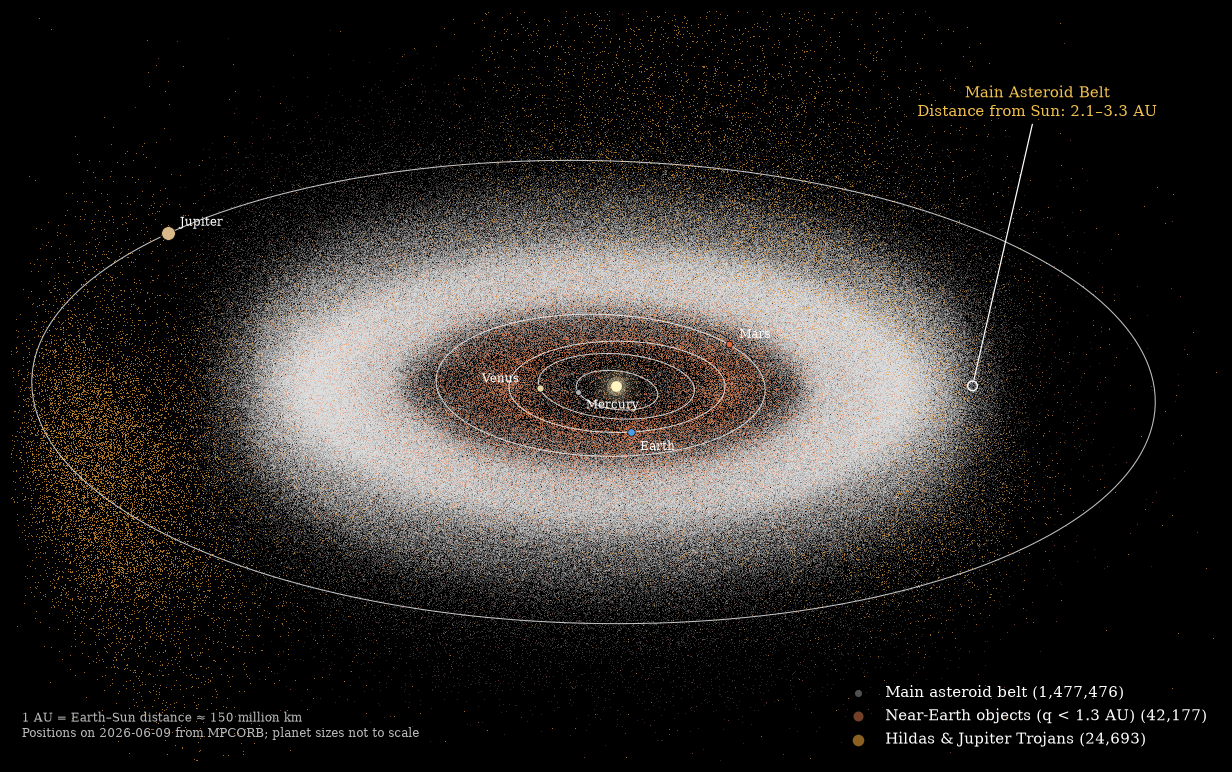

In [6]:
fig, ax = plt.subplots(figsize=(11, 7.2), dpi=110)
fig.patch.set_facecolor("black")

draw_scene(ax, extent=5.6, classes=["belt", "neo", "hilda_trojan"],
           planets=PLANETS[:5])
callout(ax, "Main Asteroid Belt\nDistance from Sun: 2.1–3.3 AU",
        xy=belt_edge_point(3.3), xytext=(3.9, 2.45))
ax.text(-5.5, -3.25, "1 AU = Earth–Sun distance ≈ 150 million km\n"
        f"Positions on {epoch_date} from MPCORB; planet sizes not to scale",
        fontsize=8, color="#bbbbbb", family="serif")
ax.legend(loc="lower right", fontsize=8, framealpha=0, markerscale=12,
          labelcolor="white", prop={"family": "serif"})
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()

# Step 6: Panel 2 — The Outer Solar System and the Kuiper Belt

Zooming out by a factor of about ten brings in Saturn, Uranus and Neptune and, beyond them, the trans-Neptunian objects. The inner belt collapses into a bright smudge around the Sun — the same 1.4 million points, now only a couple of pixels across — while the Kuiper belt appears as the blue ring outside Neptune's orbit, thickest between 40 and 48 AU (the classical belt around the 3:2 and 2:1 resonances with Neptune). The Centaurs, wandering between the giant planets, are shown in cyan.

Compare this panel with the cartoon and one difference leaps out: the real Kuiper belt looks *sparse*. The cartoon's dense band reflects the belt's presumed total population (hundreds of thousands of objects larger than 100 km); MPCORB contains only the few thousand that have actually been discovered, because at 40 AU an object of a given size is roughly 10<sup>5</sup> times fainter than in the main belt. The distribution is also lopsided: most known TNOs were found in surveys along the ecliptic and away from the galactic plane, and a snapshot on a single date freezes in each object's current position along its orbit. What you see is the *known* Solar System, which is exactly the point of using the catalogue rather than a drawing.

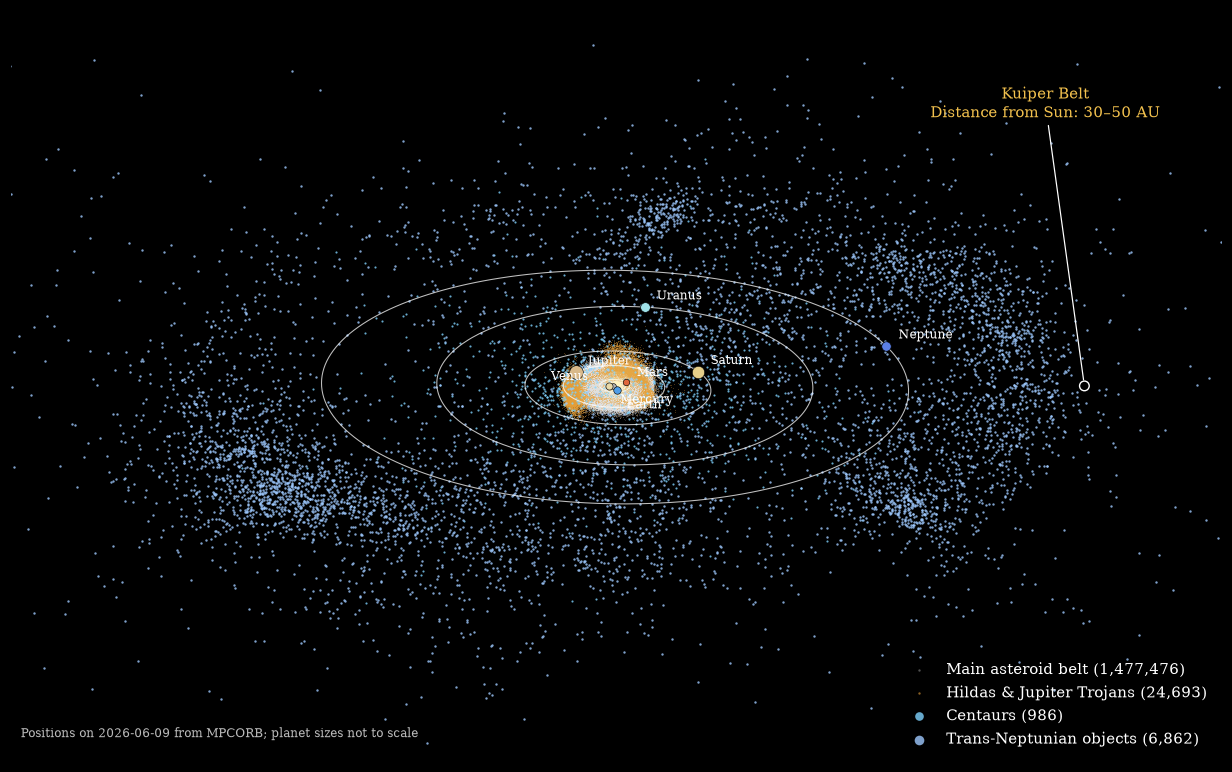

6,862 TNOs in the catalogue, 6,727 of them inside 62 AU today


In [7]:
fig, ax = plt.subplots(figsize=(11, 7.2), dpi=110)
fig.patch.set_facecolor("black")

draw_scene(ax, extent=62, classes=["belt", "hilda_trojan", "centaur", "tno"],
           size_override={"hilda_trojan": 0.15})
callout(ax, "Kuiper Belt\nDistance from Sun: 30–50 AU",
        xy=belt_edge_point(48), xytext=(44, 27))
ax.text(-61, -36, f"Positions on {epoch_date} from MPCORB; planet sizes not to scale",
        fontsize=8, color="#bbbbbb", family="serif")
ax.legend(loc="lower right", fontsize=8, framealpha=0, markerscale=4,
          labelcolor="white", prop={"family": "serif"})
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()

n_tno_in_view = np.sum((cls == "tno") & (r < 62))
print(f"{np.sum(cls == 'tno'):,} TNOs in the catalogue, {n_tno_in_view:,} of them inside 62 AU today")

# Step 7: Panel 3 — The Oort Cloud (Simulated)

The third view cannot be drawn from MPC data. The Oort cloud is *inferred*, not observed: [Oort (1950)](https://ui.adsabs.harvard.edu/abs/1950BAN....11...91O) noticed that the original orbits of long-period comets have aphelia clustered at tens of thousands of AU and arrive from all directions, and concluded that a roughly spherical reservoir of comets surrounds the Solar System. No object has ever been observed while *in* the cloud — at 20 000 AU a 10-km comet nucleus is around magnitude 60 — so the MPC's catalogues contain the visitors, never the residents.

We therefore draw a **model** cloud, following the dynamical picture established by [Duncan, Quinn & Tremaine (1987)](https://ui.adsabs.harvard.edu/abs/1987AJ.....94.1330D) and later work:

- a radial number density falling as `n(r) ∝ r^−3.5` between an inner edge near 2 000 AU and an outer edge near 200 000 AU, where the Sun's gravity gives way to the galactic tide;
- an **inner cloud** (the "Hills cloud") that is flattened toward the ecliptic, grading into an **isotropic** outer cloud beyond about 20 000 AU, where passing stars and the galactic tide have long since randomized the orbits.

We sample this density with the inverse-CDF method (for `n ∝ r^−3.5`, the number of objects per shell goes as `r^−1.5`, so the cumulative distribution is `∝ r^−0.5`) and impose the flattening by squashing each random direction's z-component by a factor that grows from 0.15 at the inner edge to 1 in the outer cloud. The real cloud contains perhaps 10<sup>11</sup>–10<sup>12</sup> comets; we draw 60 000 representative points.

**The scale problem.** The cloud is 10<sup>4</sup> times larger than the planetary system, so a to-scale picture would shrink Neptune's orbit to a fraction of a pixel; the cartoon simply cheats and draws the planets far too large. We do something honest instead: we map every heliocentric distance through `log10(r)` before projecting. Direction is preserved, so the flattened inner cloud and spherical outer cloud keep their shapes, and the guide rings mark decades in distance: 1, 10, 100, ..., 100 000 AU. Inside the log map the planets, the main belt and the Kuiper belt are the *real* MPC data from the previous two panels.

Simulated 60,000 Oort-cloud objects between 2,000 and 200,000 AU; median distance 6,556 AU


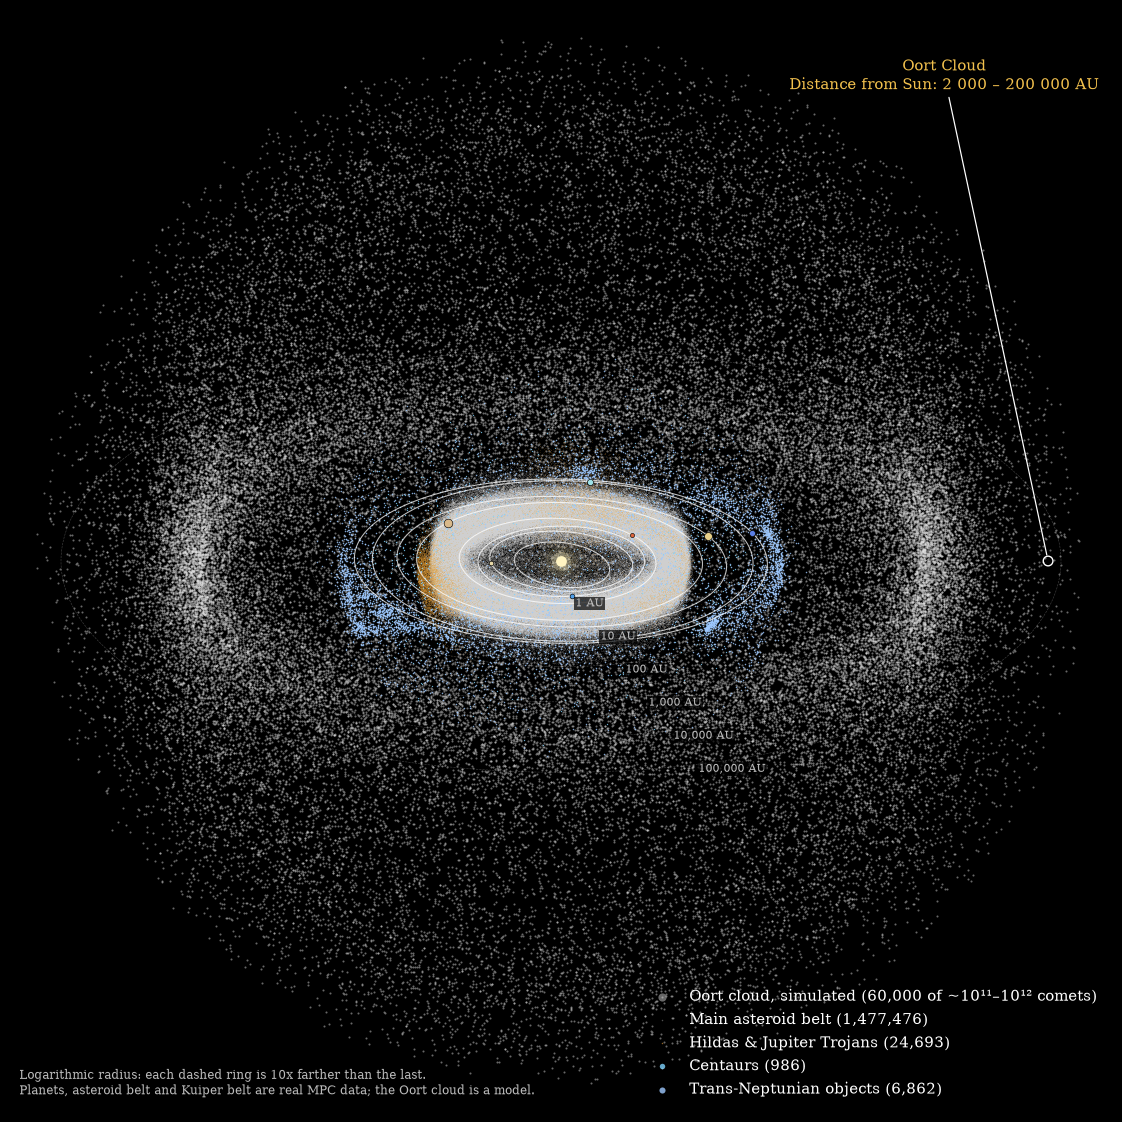

In [8]:
rng = np.random.default_rng(2026)
N_OORT = 60_000
R_IN, R_OUT = 2_000.0, 200_000.0          # AU

# Radial distances: number per shell dN/dr ∝ r^-1.5  (n ∝ r^-3.5 times 4 pi r^2)
u = rng.random(N_OORT)
r_oort = (R_IN**-0.5 - u * (R_IN**-0.5 - R_OUT**-0.5))**-2

# Directions: isotropic, then flatten the inner cloud toward the ecliptic
vec = rng.normal(size=(N_OORT, 3))
flatten = np.clip(r_oort / 20_000.0, 0.15, 1.0)   # 0.15 at the inner edge -> 1 beyond 20 000 AU
vec[:, 2] *= flatten
vec /= np.linalg.norm(vec, axis=1)[:, None]
oort_xyz = vec * r_oort[:, None]
print(f"Simulated {N_OORT:,} Oort-cloud objects between {R_IN:,.0f} and {R_OUT:,.0f} AU; "
      f"median distance {np.median(r_oort):,.0f} AU")

# Logarithmic radial map: 0.1 AU -> 0, 1 AU -> 1, ..., 100 000 AU -> 6
def log_map(rr):
    return np.log10(np.maximum(rr, 0.1)) + 1.0

fig, ax = plt.subplots(figsize=(11, 10), dpi=110)
fig.patch.set_facecolor("black")

# Guide rings at decades in distance (drawn in the ecliptic plane, then projected)
theta = np.linspace(0, 2 * np.pi, 400)
for r_ring in [1, 10, 100, 1_000, 10_000, 100_000]:
    rp = log_map(r_ring)
    X, Y, _ = project(rp * np.cos(theta), rp * np.sin(theta), np.zeros_like(theta))
    ax.plot(X, Y, color="white", lw=0.4, alpha=0.25, zorder=1, ls="--")
    Xl, Yl, _ = project(0.0, -rp, 0.0)
    ax.text(Xl, Yl - 0.05, f"{r_ring:,} AU", ha="center", va="top", fontsize=7,
            color="#c0c0c0", family="serif", zorder=8,
            bbox=dict(facecolor="black", edgecolor="none", alpha=0.7, pad=1))

# The Oort cloud itself
X, Y, D = project(*radial_remap(oort_xyz[:, 0], oort_xyz[:, 1], oort_xyz[:, 2], log_map))
order = np.argsort(D)
ax.scatter(X[order], Y[order], s=1.8, color="#e6e6e6", alpha=0.45, lw=0, zorder=2,
           label=f"Oort cloud, simulated ({N_OORT:,} of ~10¹¹–10¹² comets)", rasterized=True)

# The real planetary system inside it, through the same log map
draw_scene(ax, extent=6.6, y_extent=6.6, classes=["belt", "hilda_trojan", "centaur", "tno"],
           radial_map=log_map, label_planets=False, size_scale=0.4,
           size_override={"hilda_trojan": 0.15})
callout(ax, "Oort Cloud\nDistance from Sun: 2 000 – 200 000 AU",
        xy=project(*radial_remap(70_000 * np.cos(np.radians(-AZIM)),
                                 70_000 * np.sin(np.radians(-AZIM)), 0.0, log_map))[:2],
        xytext=(4.6, 5.6))
ax.text(-6.5, -6.4, "Logarithmic radius: each dashed ring is 10x farther than the last.\n"
        "Planets, asteroid belt and Kuiper belt are real MPC data; the Oort cloud is a model.",
        fontsize=8, color="#bbbbbb", family="serif")
ax.legend(loc="lower right", fontsize=8, framealpha=0, markerscale=4,
          labelcolor="white", prop={"family": "serif"})
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()

### Reading the figure

In log-radius the nested structure is easy to read: the tight bright core is the terrestrial planets and the main belt (the first two rings, 1 and 10 AU), the giant planets and the blue Kuiper belt sit between the 10 AU and 100 AU rings, the handful of detached objects and scattered-disc TNOs that happen to lie beyond 100 AU today drift outside them, and then — after a wide, genuinely empty gap of about a decade in distance — the Oort cloud begins. The flattened inner cloud shows up as the brighter band along the ecliptic at the left and right limbs — the line of sight runs lengthwise through the disc there — and merges into the round outer cloud, whose far side rises above the planetary system and near side hangs below it, just as in the cartoon, but here because the geometry demands it.

Change `ELEV` and `AZIM` in Step 4 and re-run to fly the camera around; set `ELEV = 90` for a top-down map.

# Step 8: The Triptych

Finally, the three panels side by side, in the layout of the original infographic. The first two are the real catalogue; the third is the model cloud wrapped around it.

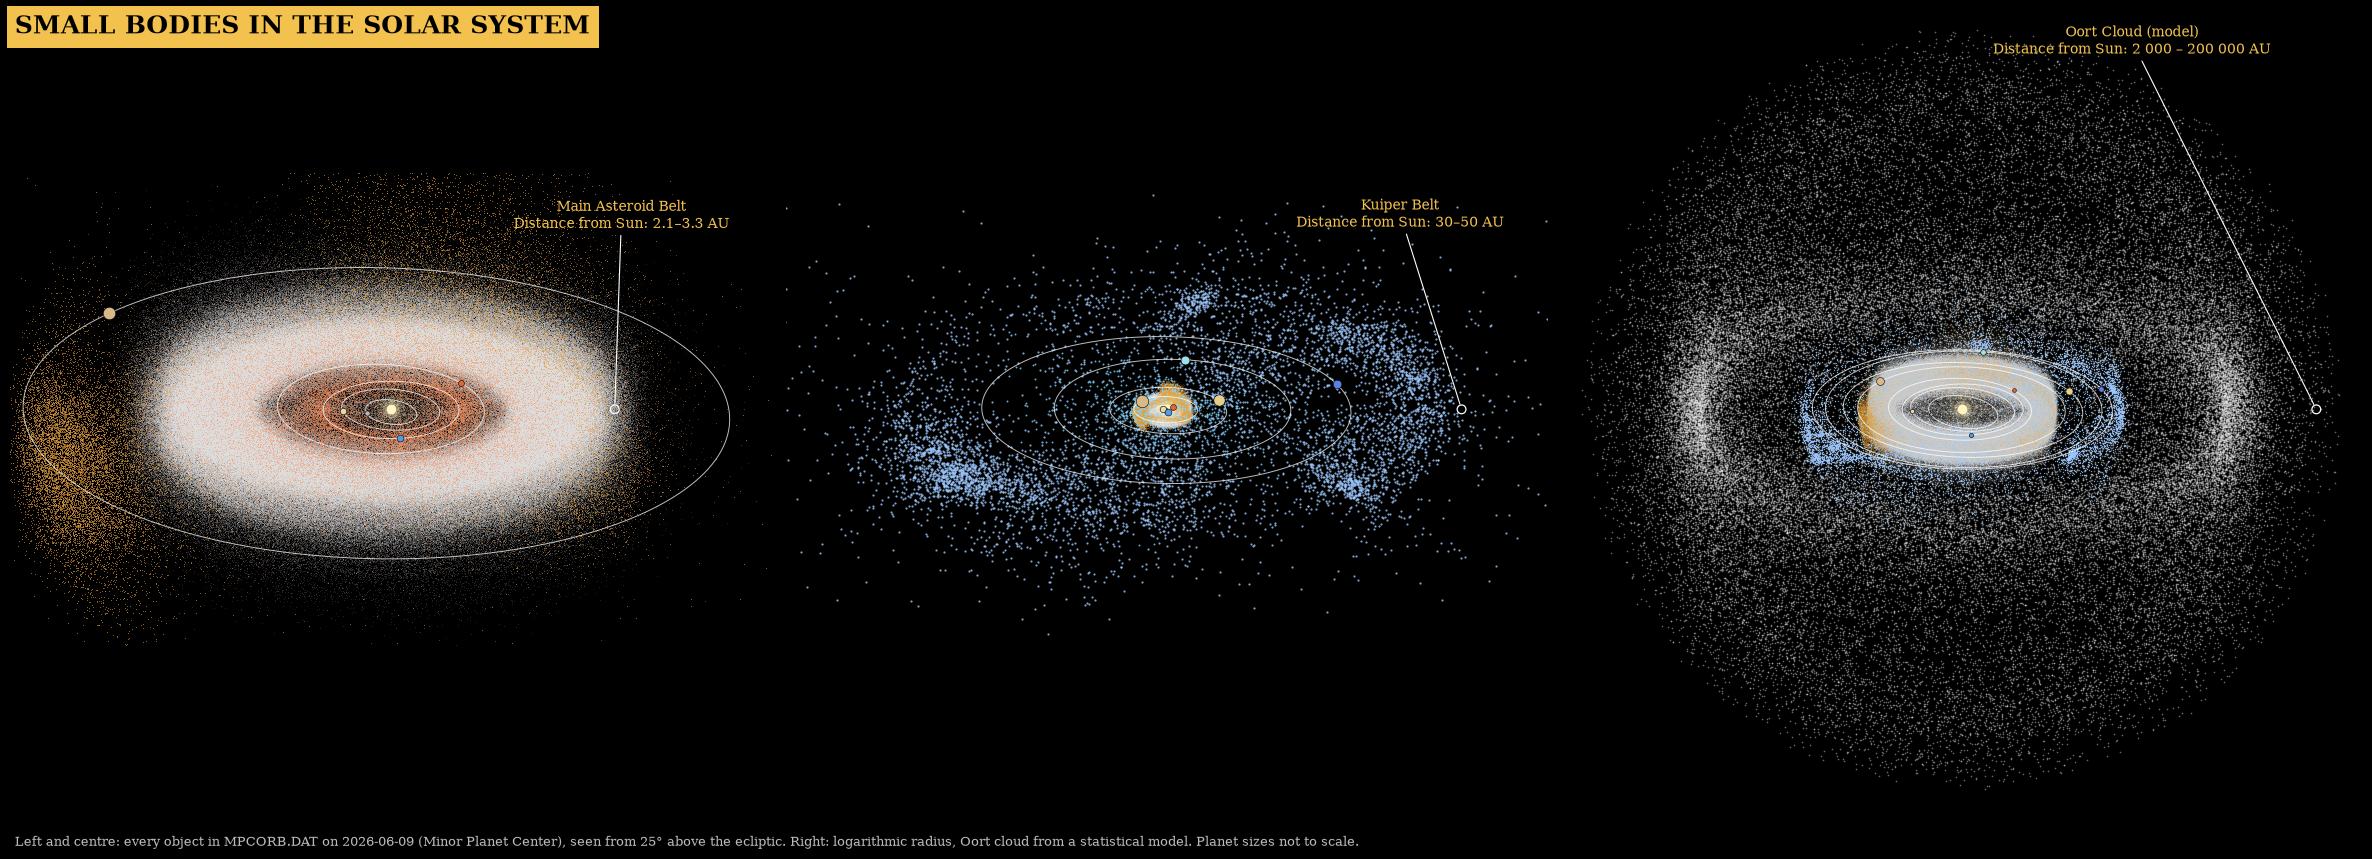

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(24, 9), dpi=100,
                         gridspec_kw={"width_ratios": [1, 1, 1.05]})
fig.patch.set_facecolor("black")

draw_scene(axes[0], extent=5.6, classes=["belt", "neo", "hilda_trojan"], planets=PLANETS[:5],
           label_planets=False)
callout(axes[0], "Main Asteroid Belt\nDistance from Sun: 2.1–3.3 AU",
        xy=belt_edge_point(3.3), xytext=(3.4, 2.6))

draw_scene(axes[1], extent=62, classes=["belt", "hilda_trojan", "centaur", "tno"],
           label_planets=False, size_override={"hilda_trojan": 0.15})
callout(axes[1], "Kuiper Belt\nDistance from Sun: 30–50 AU",
        xy=belt_edge_point(48), xytext=(38, 29))

X, Y, D = project(*radial_remap(oort_xyz[:, 0], oort_xyz[:, 1], oort_xyz[:, 2], log_map))
order = np.argsort(D)
axes[2].scatter(X[order], Y[order], s=1.4, color="#e6e6e6", alpha=0.45, lw=0, zorder=2,
                rasterized=True)
draw_scene(axes[2], extent=6.6, y_extent=6.6, classes=["belt", "hilda_trojan", "centaur", "tno"],
           radial_map=log_map, label_planets=False, size_scale=0.4,
           size_override={"hilda_trojan": 0.15})
callout(axes[2], "Oort Cloud (model)\nDistance from Sun: 2 000 – 200 000 AU",
        xy=project(*radial_remap(70_000 * np.cos(np.radians(-AZIM)),
                                 70_000 * np.sin(np.radians(-AZIM)), 0.0, log_map))[:2],
        xytext=(2.8, 5.8))

fig.text(0.012, 0.955, "SMALL BODIES IN THE SOLAR SYSTEM", fontsize=18, color="black",
         family="serif", weight="bold", va="center",
         bbox=dict(facecolor="#f2c14e", edgecolor="none", pad=6))
fig.text(0.012, 0.045, f"Left and centre: every object in MPCORB.DAT on {epoch_date} "
         "(Minor Planet Center), seen from 25° above the ecliptic. "
         "Right: logarithmic radius, Oort cloud from a statistical model. Planet sizes not to scale.",
         fontsize=9.5, color="#bbbbbb", family="serif")
fig.subplots_adjust(left=0.01, right=0.99, top=0.98, bottom=0.08, wspace=0.02)
fig.savefig("small_bodies_three_scales.png", dpi=150, facecolor="black")
plt.show()

# Summary

In this tutorial we:

1. **Downloaded and parsed** the full [`MPCORB.DAT`](https://minorplanetcenter.net/iau/MPCORB.html) catalogue and placed all ~1.5 million objects at their positions on the common epoch with a vectorized Kepler solver, keeping the distant populations this time
2. **Fetched the planets** for the same date from JPL Horizons via REBOUND, in the same units and frame
3. **Built an oblique camera** — a rotation, a tilt and an orthographic projection in a few lines of `numpy`, with depth ordering — to reproduce the tilted viewpoint of the infographic
4. **Drew the inner Solar System** from real data: the main belt, the Trojan swarms and the near-Earth objects between the terrestrial planets and Jupiter
5. **Drew the outer Solar System** from real data, and saw that the *known* Kuiper belt is sparse and lopsided — a picture of discovery, not of the full population
6. **Simulated an Oort cloud** with an `r^−3.5` density law and a flattened inner cloud, and drew it around the real planetary system on a logarithmic radial scale so that four orders of magnitude fit in one panel
7. **Assembled** the three views into a single infographic-style figure

### Ideas to extend

- Colour the Kuiper belt by dynamical class (classical, resonant, scattered) using `a` and `e`, or add the resonance circles at 39.4 and 47.8 AU
- Read the MPC's comet orbit file and draw the aphelion directions of long-period comets — the actual evidence for the Oort cloud — on the third panel
- Animate the camera azimuth, or the epoch, by re-running Steps 2–3 for a sequence of dates

### Further Resources

- [ESA: *Small objects in the Solar System* infographic](https://www.esa.int/ESA_Multimedia/Search?SearchText=Small+objects+in+the+Solar+System)
- [Oort (1950), *The structure of the cloud of comets surrounding the Solar System*, BAN 11, 91](https://ui.adsabs.harvard.edu/abs/1950BAN....11...91O)
- [Duncan, Quinn & Tremaine (1987), *The formation and extent of the Solar System comet cloud*, AJ 94, 1330](https://ui.adsabs.harvard.edu/abs/1987AJ.....94.1330D)
- [MPCORB page](https://minorplanetcenter.net/iau/MPCORB.html) and the [MPC data page (bulk orbit files)](https://minorplanetcenter.net/data)
- [Minor Planet Orbit Format documentation](https://docs.minorplanetcenter.net/mpc-ops-docs/orbits/minor-planet-orbit-format/)
- [Companion tutorial: The Kirkwood Gaps](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_kirkwood/)
- [Companion tutorial: Plotting Asteroid Orbits](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_plotting/)

For questions or feedback, contact the MPC via the [Jira Helpdesk](https://mpc-service.atlassian.net/servicedesk/customer/portal/13/create/148).